In [23]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("SERPAPI_KEY")
from serpapi.google_search import GoogleSearch


In [24]:
params = {
  "engine": "google_flights",
  "departure_id": "FRA", # Frankfurt airport to -> Barcelona, Bu Departure_id birden fazla parametre alabilir
  "arrival_id": "BCN", # Ve bu alana da birden fazla arrival_id yazabiliyoruz
  "currency": "EUR",
  "type": "2", # Type 2 demek One-Way. Diğerleri ise 1- Round-Trip (Default), 3-Multi-City birden çok şehir üzerinden seyahet
  "outbound_date": "2026-05-21",
  "api_key": api_key,
   "no_cache": False,
   #"travel_class": "1" -> Bu Default değeri yani Economy.,
   #"deep_search": True -> Bir de böyle bir özellik, böyle yaptığımızda sonuçlar gerçeğe daha yakın oluyor ama api cost ve fetch süresi artıyor
   #"sort_by": "1" (Default) -> Top Flights a göre sıralama demek yani hem fiyatı iyi hem de süresi, "2" diye var o da en ucuzu getir
}

import serpapi



In [25]:
search = GoogleSearch(params)
results = search.get_dict()
best_flights = results["best_flights"]

In [26]:
best_flights

[{'flights': [{'departure_airport': {'name': 'Frankfurt Airport',
     'id': 'FRA',
     'time': '2026-05-21 14:10'},
    'arrival_airport': {'name': 'Josep Tarradellas Barcelona-El Prat Airport',
     'id': 'BCN',
     'time': '2026-05-21 16:15'},
    'duration': 125,
    'airplane': 'Airbus A321',
    'airline': 'Lufthansa',
    'airline_logo': 'https://www.gstatic.com/flights/airline_logos/70px/LH.png',
    'travel_class': 'Economy',
    'flight_number': 'LH 1132',
    'legroom': '30 in',
    'extensions': ['Average legroom (30 in)',
     'Wi-Fi for a fee',
     'Carbon emissions estimate: 117 kg']}],
  'total_duration': 125,
  'carbon_emissions': {'this_flight': 118000,
   'typical_for_this_route': 110000,
   'difference_percent': 7},
  'price': 212,
  'type': 'One way',
  'airline_logo': 'https://www.gstatic.com/flights/airline_logos/70px/LH.png',
  'booking_token': 'WyJDalJJT0ZOT05VbGZYMXBwWjNkQlJISk1UbmRDUnkwdExTMHRMWFozYm5reE1DMXVNa0ZCUVVGQlIyNTNhVEF3VERKSU9WZEJFZ1pNU0RFeE16SWF

In [27]:
for flight in best_flights:
    print("Airlane: " + flight["flights"][0]["airline"])
    print("Price: " + str(flight["price"]))
    print("Departure Time: " + flight["flights"][0]["departure_airport"]["time"])
    print("Arrival Time: " + flight["flights"][0]["arrival_airport"]["time"])
    print("Total Duration: " + str(flight["total_duration"]) +" minutes")
    print("-------------------------------------------------------------------------")


Airlane: Lufthansa
Price: 212
Departure Time: 2026-05-21 14:10
Arrival Time: 2026-05-21 16:15
Total Duration: 125 minutes
-------------------------------------------------------------------------
Airlane: Condor
Price: 239
Departure Time: 2026-05-21 20:10
Arrival Time: 2026-05-21 22:10
Total Duration: 120 minutes
-------------------------------------------------------------------------
Airlane: Condor
Price: 240
Departure Time: 2026-05-21 14:10
Arrival Time: 2026-05-21 16:05
Total Duration: 115 minutes
-------------------------------------------------------------------------


### Api içersinde other_flights diye bir parametre daha var bir de oradaki verileri bakıcam

In [28]:
other_flights = results["other_flights"]

In [29]:
for flight in other_flights:
    print("Airlane: " + flight["flights"][0]["airline"])
    print("Price: " + str(flight["price"]))
    print("Departure Time: " + flight["flights"][0]["departure_airport"]["time"])
    print("Arrival Time: " + flight["flights"][0]["arrival_airport"]["time"])
    print("Total Duration: " + str(flight["total_duration"]) +" minutes")
    print("-------------------------------------------------------------------------")

Airlane: Lufthansa
Price: 245
Departure Time: 2026-05-21 07:30
Arrival Time: 2026-05-21 09:35
Total Duration: 125 minutes
-------------------------------------------------------------------------
Airlane: Lufthansa
Price: 250
Departure Time: 2026-05-21 16:10
Arrival Time: 2026-05-21 18:15
Total Duration: 125 minutes
-------------------------------------------------------------------------
Airlane: Brussels Airlines
Price: 252
Departure Time: 2026-05-21 09:00
Arrival Time: 2026-05-21 10:10
Total Duration: 325 minutes
-------------------------------------------------------------------------
Airlane: Brussels Airlines
Price: 252
Departure Time: 2026-05-21 16:25
Arrival Time: 2026-05-21 17:30
Total Duration: 245 minutes
-------------------------------------------------------------------------
Airlane: Lufthansa
Price: 264
Departure Time: 2026-05-21 11:00
Arrival Time: 2026-05-21 13:05
Total Duration: 125 minutes
-------------------------------------------------------------------------
Airl

## Uçuşa Özgü Booking URL'leri

Google Flights API'de **iki adımlı bir flow** var:
1. **1. İstek** → Normal arama → Her uçuşta `booking_token` alanı gelir
2. **2. İstek** → `booking_token` parametresiyle yeni istek → O uçuşa özel booking seçenekleri (havayolu sitesi, Google Flights linki vb.) döner

Önce token'ın response'da nerede olduğunu görelim:

In [38]:
# best_flights içindeki ilk uçuşun booking_token'ını çek
first_flight = best_flights[0]
token = first_flight.get("booking_token")

print("Airline  :", first_flight["flights"][0]["airline"])
print("Price    :", first_flight["price"], "EUR")
print("Departure:", first_flight["flights"][0]["departure_airport"]["time"])
print("Arrival  :", first_flight["flights"][0]["arrival_airport"]["time"])
print()
print("booking_token: " + token)

Airline  : Lufthansa
Price    : 212 EUR
Departure: 2026-05-21 14:10
Arrival  : 2026-05-21 16:15

booking_token: WyJDalJJT0ZOT05VbGZYMXBwWjNkQlJISk1UbmRDUnkwdExTMHRMWFozYm5reE1DMXVNa0ZCUVVGQlIyNTNhVEF3VERKSU9WZEJFZ1pNU0RFeE16SWFDd2lMcFFFUUFob0RSVlZTT0J4d2dNRUIiLFtbIkZSQSIsIjIwMjYtMDUtMjEiLCJCQ04iLG51bGwsIkxIIiwiMTEzMiJdXV0=


In [33]:
# 2. adım: booking_token ile o uçuşa özgü booking seçeneklerini çek
booking_params = {
    "engine": "google_flights",
    "booking_token": token,
    "departure_id": first_flight["flights"][0]["departure_airport"]["id"],
    "arrival_id":   first_flight["flights"][0]["arrival_airport"]["id"],
    "outbound_date": first_flight["flights"][0]["departure_airport"]["time"][:10],
    "type": "2",
    "currency": "EUR",
    "api_key": api_key,
    "no_cache": True,
}

booking_search = GoogleSearch(booking_params)
booking_results = booking_search.get_dict()
booking_results

{'search_metadata': {'id': '69f08e62d649a906e0c651ef',
  'status': 'Success',
  'json_endpoint': 'https://serpapi.com/searches/D9muqEspjwy_F3bq-Hj_Yw/69f08e62d649a906e0c651ef.json',
  'created_at': '2026-04-28 10:39:30 UTC',
  'processed_at': '2026-04-28 10:39:30 UTC',
  'google_flights_url': 'https://www.google.com/travel/flights?hl=en&gl=us&curr=EUR&tfs=CBwQAhpAEgoyMDI2LTA1LTIxIiAKA0ZSQRIKMjAyNi0wNS0yMRoDQkNOKgJMSDIEMTEzMmoHCAESA0ZSQXIHCAESA0JDTkABSAFwAZgBAg&tfu=EgIIAQ',
  'raw_html_file': 'https://serpapi.com/searches/D9muqEspjwy_F3bq-Hj_Yw/69f08e62d649a906e0c651ef.html',
  'prettify_html_file': 'https://serpapi.com/searches/D9muqEspjwy_F3bq-Hj_Yw/69f08e62d649a906e0c651ef.prettify',
  'total_time_taken': 10.28},
 'search_parameters': {'engine': 'google_flights',
  'hl': 'en',
  'gl': 'us',
  'type': '2',
  'departure_id': 'FRA',
  'arrival_id': 'BCN',
  'outbound_date': '2026-05-21',
  'booking_token': 'WyJDalJJT0ZOT05VbGZYMXBwWjNkQlJISk1UbmRDUnkwdExTMHRMWFozYm5reE1DMXVNa0ZCUVVGQlIy

In [35]:
# Dönen booking seçeneklerini ve URL'leri göster
booking_options = booking_results.get("booking_options", [])

if not booking_options:
    print("booking_options boş geldi — response'u yukarıda incele")
else:
    for opt in booking_options:
        book_with = opt.get("book_with", "")
        price     = opt.get("price", "?")
        link      = opt.get("booking_request", {}).get("url", "") or opt.get("url", "")
        print(f"{book_with:<30} {price} EUR")
        print(f"  -> {link}")
        print()

                               ? EUR
  -> 

                               ? EUR
  -> 

                               ? EUR
  -> 

                               ? EUR
  -> 

                               ? EUR
  -> 

                               ? EUR
  -> 



### Tüm uçuşları booking_token ile tara ve en ucuz linki seç

Her uçuş için booking URL'si döndüren yardımcı fonksiyon:

In [36]:
def get_booking_url(flight_result: dict) -> str:
    """booking_token ile Google Flights'tan o uçuşa özel URL döndürür."""
    token = flight_result.get("booking_token")
    if not token:
        return ""
    res = GoogleSearch({
        "engine": "google_flights",
        "booking_token": token,
        "currency": "EUR",
        "api_key": api_key,
        "no_cache": True,
    }).get_dict()
    options = res.get("booking_options", [])
    if not options:
        return res.get("search_metadata", {}).get("google_flights_url", "")
    # En ucuz seçeneğin URL'ini döndür
    cheapest = min(options, key=lambda o: o.get("price", float("inf")))
    return (
        cheapest.get("booking_request", {}).get("url")
        or cheapest.get("url", "")
    )


# Sadece best_flights'ın ilk 3 uçuşunu test et (API credit tasarrufu için)
for flight in best_flights[:3]:
    url = get_booking_url(flight)
    print(f"{flight['flights'][0]['airline']:<20} {flight['price']} EUR")
    print(f"  {url}")
    print()

Lufthansa            212 EUR
  

Condor               239 EUR
  

Condor               240 EUR
  



In [40]:
def get_flight_url(flight_result: dict, all_results: dict) -> str:
    """
    SerpAPI'nin search_metadata içinde döndürdüğü google_flights_url'i kullanır.
    Bu URL doğrudan o arama sonuçlarının Google Flights sayfasını açar.
    """
    # SerpAPI'nin ürettiği gerçek Google Flights URL'i (tfs parametreli)
    url = all_results.get("search_metadata", {}).get("google_flights_url", "")
    if url:
        return url

    # Yoksa arama parametrelerinden basit URL oluştur (fallback)
    dep  = flight_result["flights"][0]["departure_airport"]["id"]
    arr  = flight_result["flights"][0]["arrival_airport"]["id"]
    date = flight_result["flights"][0]["departure_airport"]["time"][:10]
    return f"https://www.google.com/travel/flights?q=Flights+{dep}+to+{arr}+{date}"


# Test
first = best_flights[0]
url = get_flight_url(first, results)

print(f"Airline : {first['flights'][0]['airline']}")
print(f"Route   : {first['flights'][0]['departure_airport']['id']} → {first['flights'][0]['arrival_airport']['id']}")
print(f"Price   : {first['price']} EUR")
print(f"\nURL:\n{url}")


Airline : Lufthansa
Route   : FRA → BCN
Price   : 212 EUR

URL:
https://www.google.com/travel/flights?hl=en&gl=us&curr=EUR&tfs=CBwQAhoeEgoyMDI2LTA1LTIxagcIARIDRlJBcgcIARIDQkNOQAFIAXABmAEC&tfu=EgIIAQ


### Yeni Kısıma geçtik
Şimdi Price Insight parametresini kullanarak fiyatların ne kadar yüksek veya düşük olduğunu incelicez eğerki fazla yüksekse, hemen otobüslerle buraya varılır mı taktiğini deneyebilmek için bizlere ilham olucak. Bunu nasıl yapcaz? Api içersinde price_history diye bir değişken daha dönüyor

## Google Flight Price Insight

<img src="price_insight.png" width="800"/>

In [36]:
results = search.get_dict()
price_insights = results["price_insights"]

In [50]:
price_history = price_insights["price_history"]

Bu "price_history" içersinde timestamp ve fiyat bilgisi var şu şekilde -> [timestamp, price].
Ve 61 gün kadar geçmişe gidebiliyor. Buradan gelen veriyi işleyerek ortalamada ne kadar pahalı ne kadar ucuz aslında bir fikir alabiliriz.

In [59]:
#for price in price_history:
#   print("timestamp: ", price[0])
#   print("price: ", price[1])

In [48]:
import pandas as pd
import seaborn as sns

In [51]:
df = pd.DataFrame(price_history, columns=["timestamp","price"])
df["date"] = pd.to_datetime(df["timestamp"], unit="s")

In [55]:
df

,timestamp,price,date
0,1768431600,133,2026-01-14 23:00:00
1,1768518000,133,2026-01-15 23:00:00
2,1768604400,133,2026-01-16 23:00:00
3,1768690800,133,2026-01-17 23:00:00
4,1768777200,133,2026-01-18 23:00:00
...,...,...,...
57,1773356400,102,2026-03-12 23:00:00
58,1773442800,102,2026-03-13 23:00:00
59,1773529200,141,2026-03-14 23:00:00
60,1773615600,141,2026-03-15 23:00:00


# Yeni Bölüme geçtik!
Şimdiki amacımız bulunduğumuz havalimanında etrafa en ucuz uçuşları çekmek! Aynı aşağıdaki resimde olduğu gibi.
Bu ne işe yarıyacak? Gelen uçuş bilgisi ortalama fiyattan yüksekse veya alternatif rotaları da denemek istersek, başlangıç noktamızdan en ucuza gidilen yerleri çekeriz ve bu gelen yerler eğerki varcağımız yere makul derecede yakınsa o zaman bi otobüs tren seçeneklerine de bakabiliriz :)

<img src="discover_word.png" width="600"/>
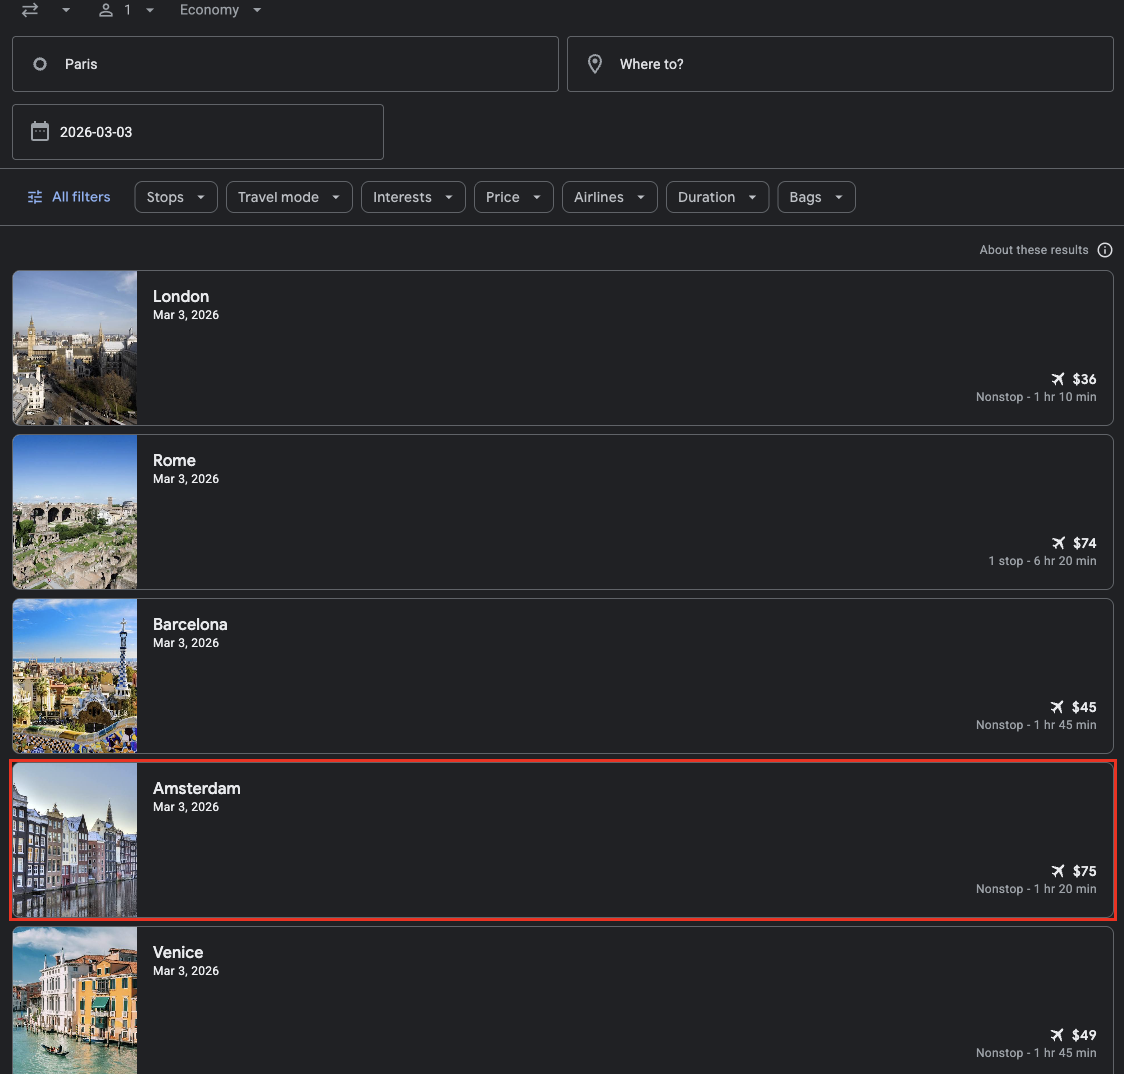

In [ ]:
import serpapi

params = {
  "engine": "google_travel_explore",
  "departure_id": "BRU",
  "currency": "USD",
  "type": "2",
}
client = serpapi.Client(api_key=api_key)
results = client.search(params)
destinations = results["destinations"]

In [ ]:
destinations

In [62]:
from pydantic import  BaseModel

In [67]:
class Flight(BaseModel):
    city: str
    country: str
    latitude: float
    longitude: float
    price: int | None = None
    duration: int
    airline: str
    link: str

In [ ]:
import pandas as pd

rows = []
for flight in destinations:
    if "flight_price" not in flight:
        continue
    rows.append({
        "city":      flight["name"],
        "country":   flight["country"],
        "latitude":  flight["gps_coordinates"]["latitude"],
        "longitude": flight["gps_coordinates"]["longitude"],
        "price":     flight["flight_price"],
        "duration":  flight["flight_duration"],
        "airline":   flight["airline"],
        "link":      flight["link"],
        "iata":      flight["destination_airport"]["code"],
    })

df = pd.DataFrame(rows).sort_values("price").reset_index(drop=True)
df

## Proximity Filter: Find cities close to your actual destination

If flights to your real destination are expensive, find cheap flights to *nearby* cities and take a bus/train for the last leg.

In [114]:
import math

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lam = math.radians(lon2 - lon1)
    a = math.sin(d_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lam / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

# --- Mock target: change this to any city you want ---
TARGET = {
    "city": "Athens",
    "latitude": 40.191163,
    "longitude": 29.004465,
}
MAX_DISTANCE_KM = 500  # bus/train feasibility threshold

df["distance_to_target_km"] = df.apply(
    lambda row: haversine_km(row["latitude"], row["longitude"], TARGET["latitude"], TARGET["longitude"]),
    axis=1
)

nearby = df[df["distance_to_target_km"] <= MAX_DISTANCE_KM][["city", "country", "price", "duration","airline"]].sort_values("price").reset_index(drop=True)

print(f"Cheap flights within {MAX_DISTANCE_KM}km of {TARGET['city']}:\n")
nearby

Cheap flights within 500km of Athens:



,city,country,price,duration,airline
0,Istanbul,Türkiye,81,205,AJet
1,Antalya,Türkiye,97,525,SWISS and Edelweiss Air
2,Mykonos,Greece,108,635,Vueling
